mu_fit: 5.843333333333334, sigma_fit: 0.8253012917851409
mu_compute: 5.843333333333334, sigma_compute: 0.8253012917851409
mise1 0.0025922270842203736
mise2 0.008708115271239355
mise3 0.005077132089448007
1.0
mise4 0.018041619894146193


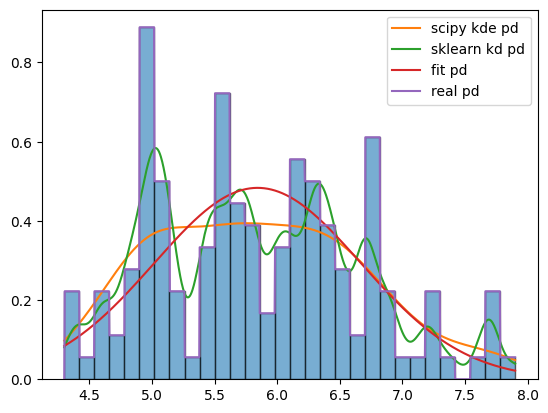

In [37]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm, gaussian_kde

from sklearn.datasets import load_iris
from sklearn.neighbors import KernelDensity


X = load_iris().data[:, 0]

mu_fit, sigma_fit = norm.fit(X)
print(f'mu_fit: {mu_fit}, sigma_fit: {sigma_fit}')

mu_compute = np.mean(X)
sigma_compute = np.std(X)
print(f'mu_compute: {mu_compute}, sigma_compute: {sigma_compute}')

x_samples = np.linspace(np.min(X), np.max(X), 1000)
pd_fit = norm.pdf(x_samples, mu_compute, sigma_compute)


kde = gaussian_kde(X)
pd_kde = kde(x_samples)

mise = np.mean((pd_fit - pd_kde)**2)
print('mise1', mise)


model = KernelDensity(kernel='gaussian', bandwidth=0.08)
model.fit(X.reshape(-1, 1))
pd_kd_sklearn = model.score_samples(x_samples.reshape(-1, 1))
pd_kd_sklearn = np.exp(pd_kd_sklearn)

mise = np.mean((pd_fit - pd_kd_sklearn)**2)
print('mise2', mise)

mise = np.mean((pd_kde - pd_kd_sklearn)**2)
print('mise3', mise)


n, bins, patches = plt.hist(X, bins=30, edgecolor='black', alpha=0.6, density=True)
# print(bins.shape)
print(np.sum(n * np.diff(bins)))


def real_density(x, n, bins):
    index = np.searchsorted(bins, x)

    density = 0
    if index > 0 and index <= 30:
        density = n[index-1]

    return density

pd_real = [real_density(x, n, bins) for x in x_samples]
mise = np.mean((pd_real - pd_kd_sklearn)**2)
print('mise4', mise)


plt.plot(x_samples, pd_kde, label='scipy kde pd')
plt.plot(x_samples, pd_kd_sklearn, label='sklearn kd pd')
plt.plot(x_samples, pd_fit, label='fit pd')
plt.plot(x_samples, pd_real, label='real pd')

plt.legend()
plt.show()